## Clusterizaciòn de codificaciones

## Importación de librerias necesarias

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
from pyspark.sql import functions as F, types as T, DataFrame, Window
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.cluster import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.clustering import KMeans, KMeansModel
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import array_to_vector
from src.gold.training.pca import PCAEncoder

In [4]:
from src.utils.spark import SparkUtils
spark_utils = SparkUtils('clusterize_encodings')
spark = spark_utils.spark

2025-10-26 18:01:10.390656: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-26 18:01:10.403588: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-26 18:01:10.407233: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-26 18:01:10.417662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-26 18:01:12.145287: W tensorflow/compiler/tf2

:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-bba3aca4-8617-4a48-8146-e9c028c20acd;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 131ms :: artifacts dl 5ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

In [5]:
REGENERATE_INTERMEDIATE_TABLES = False

In [6]:
GOLD_SCHEMA = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
GOLD_SCHEMA_ENCODING = 'gold.encoding'
SCHEMA = 'silver.preprocess'

## Cargar información de codificaciones

In [7]:
main_category_encoded = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded', catalog = GOLD_SCHEMA
))

df_vectorized_pca = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca', catalog = GOLD_SCHEMA
))

Definir conjunto de embebido a probar

In [8]:
df_items_features = df_vectorized_pca.select(
    "parent_asin", F.col("pca_features").alias("features")
)

## Clusterización K-Means

### Caso Fair Embedding (Promedio sin distinción)

In [ ]:
kmeans = KMeans(
    featuresCol="features", predictionCol="cluster", k=1000,
    distanceMeasure="cosine"
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    model = kmeans.fit(df_items_features)
    model.write().overwrite().save(spark_utils.path('kmeans_model', catalog = GOLD_SCHEMA_CLUSTER))

model = KMeansModel.load(spark_utils.path('kmeans_model', catalog = GOLD_SCHEMA_CLUSTER))

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    kmeans_meta_items_clustered_equi = model.transform(df_items_features)
    (
        kmeans_meta_items_clustered_equi.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('kmeans_meta_items_clustered_equi', catalog = GOLD_SCHEMA_CLUSTER))
    )

kmeans_meta_items_clustered_equi = spark.read.format('delta').load(spark_utils.path(
    'kmeans_meta_items_clustered_equi', catalog = GOLD_SCHEMA_CLUSTER
))

### Caso TFIDF

In [ ]:
kmeans_tfidf = KMeans(
    featuresCol="features", predictionCol="cluster", k=200,
    distanceMeasure="cosine"
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    model_tfidf = kmeans_tfidf.fit(df_vectorized_tfidf)
    model_tfidf.write().overwrite().save(spark_utils.path('kmeans_model_tfidf', catalog = GOLD_SCHEMA_CLUSTER))

model_tfidf = KMeansModel.load(spark_utils.path('kmeans_model_tfidf', catalog = GOLD_SCHEMA_CLUSTER))

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    meta_items_clustered_tfidf = model_tfidf.transform(df_vectorized_tfidf)
    (
        meta_items_clustered_tfidf.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('meta_items_embeddings_tfidf_clustered', catalog = GOLD_SCHEMA_CLUSTER))
    )

meta_items_clustered_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_tfidf_clustered', catalog = GOLD_SCHEMA_CLUSTER
))

In [ ]:
meta_items_clustered_tfidf.count()

456530

## Visualizar distribución de codificaciones

In [ ]:
from src.utils.visualization.clustering import plot_cluster_distribution
from src.utils.evaluators import evaluate_clustering

### Caso Fair Embedding (Promedio sin distinción)

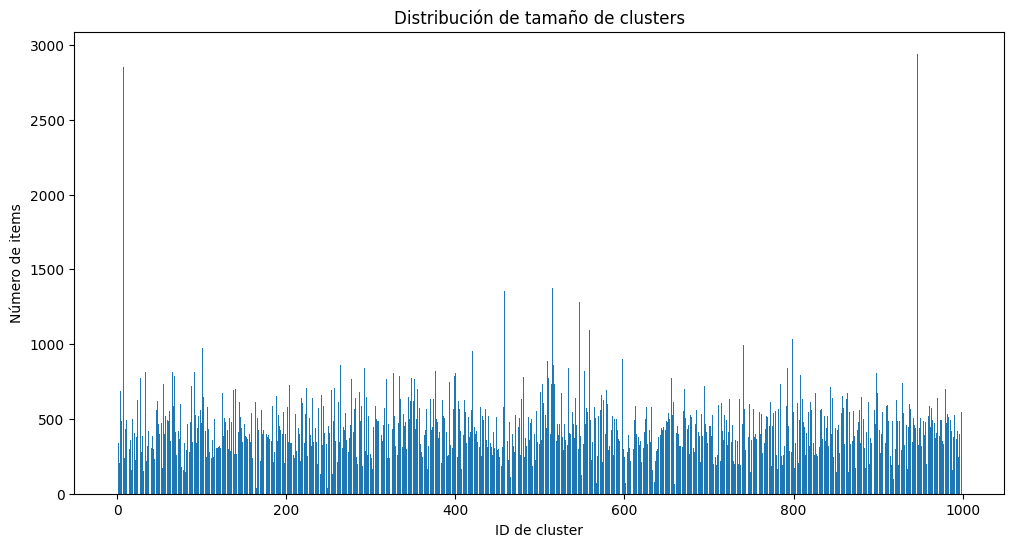

In [ ]:
plot_cluster_distribution(
    kmeans_meta_items_clustered_equi, 'cluster'
)

In [ ]:
silhouette_score_equi = evaluate_clustering(kmeans_meta_items_clustered_equi, 'features', 'cluster')

In [ ]:
silhouette_score_equi

0.02832828411842044

### Caso TFIDF

In [ ]:
avg_encoded_split_with_embeddings_counts_tfidf = (
    meta_items_clustered_tfidf
        .groupBy('cluster')
        .count()
        .orderBy('cluster')
).toPandas()

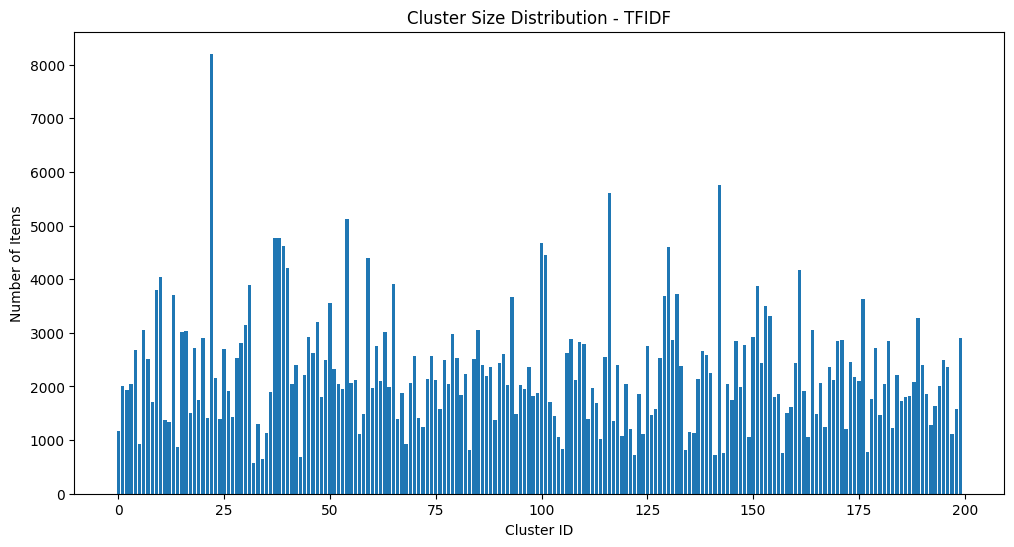

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(
    avg_encoded_split_with_embeddings_counts_tfidf['cluster'],
    avg_encoded_split_with_embeddings_counts_tfidf['count']
)
plt.title('Cluster Size Distribution - TFIDF')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.show()

In [ ]:
evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="cosine"
)

silhouette_score_tfidf = evaluator.evaluate(meta_items_clustered_tfidf)

In [ ]:
silhouette_score_tfidf

0.05384043029983401

## Muestreo de datos para clusterización

In [ ]:
df_vectorized_pca.show(1)

+-----------+--------------------+--------------------+--------------------+
|parent_asin|       sum_embedding|            features|        pca_features|
+-----------+--------------------+--------------------+--------------------+
| 140053271X|[-0.0893320512026...|[-0.0893320512026...|[1.78205077710671...|
+-----------+--------------------+--------------------+--------------------+
only showing top 1 row



In [ ]:
main_category_columns = [col for col in main_category_encoded.columns if col.startswith('main_category_')]

df_with_categories = df_vectorized_pca.join(
    main_category_encoded.select('parent_asin', *main_category_columns),
    on='parent_asin',
    how='inner'
)

samples_per_class = []
for category_col in main_category_columns:
    category_samples = (
        df_with_categories
        .filter(F.col(category_col) == 1)
        .sample(1.0, seed=42)
        .limit(10_000)
    )
    samples_per_class.append(category_samples)

df_weighted_sample = samples_per_class[0]
for sample_df in samples_per_class[1:]:
    df_weighted_sample = df_weighted_sample.union(sample_df)


In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        df_weighted_sample.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('df_weighted_sample', catalog=GOLD_SCHEMA_CLUSTER))
    )

df_weighted_sample = spark.read.format('delta').load(spark_utils.path(
    'df_weighted_sample', catalog=GOLD_SCHEMA_CLUSTER
))

In [ ]:
df_weighted_sample.count()

74200

## LSH based

In [10]:
from pyspark.ml.feature import BucketedRandomProjectionLSH
from src.utils.dataframe import SampleDataset

sample_dataset = SampleDataset()
df_items_sample_balanced = sample_dataset.sample_dataset_weighted(main_category_encoded, 'main_category')

Counts: [Row(main_category='computers', count=92874), Row(main_category='cell_phones_accessories', count=157722), Row(main_category='office_products', count=4583), Row(main_category='camera_photo', count=47079), Row(main_category='industrial_scientific', count=10148), Row(main_category='car_electronics', count=5454), Row(main_category='amazon_home', count=4163), Row(main_category='home_audio_theater', count=25586), Row(main_category='all_electronics', count=108921)]
Sampling ratios: {'computers': 1.698236320175722, 'cell_phones_accessories': 1.0, 'office_products': 34.414575605498584, 'camera_photo': 3.350156120563309, 'industrial_scientific': 15.542175798186836, 'car_electronics': 28.91859185918592, 'amazon_home': 37.88662022579871, 'home_audio_theater': 6.164386774017041, 'all_electronics': 1.4480403228027654}


In [11]:
df_vectorized_pca_sample_balanced = df_items_sample_balanced.alias('A').join(
    df_vectorized_pca.alias('B'),
    on='parent_asin',
    how='inner'
).select('B.*')

In [12]:
if True:
    (
        df_vectorized_pca_sample_balanced
            .write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('df_vectorized_pca_sample_balanced', catalog=GOLD_SCHEMA_CLUSTER))
    )

df_vectorized_pca_sample_balanced = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca_sample_balanced', catalog=GOLD_SCHEMA_CLUSTER
))

In [14]:
cosine_threshold = 0.8
num_neighbors = 10
euclidean_threshold = (2 * (1 - cosine_threshold)) ** 0.5

In [15]:
lsh = BucketedRandomProjectionLSH(
    inputCol="pca_features",
    outputCol="hashes",
    bucketLength=1.0,
    numHashTables=5
)

In [16]:
lsh_model = lsh.fit(df_vectorized_pca_sample_balanced)

In [17]:
similar_pairs = lsh_model.approxSimilarityJoin(
    df_vectorized_pca_sample_balanced.alias("a"), 
    df_vectorized_pca_sample_balanced.alias("b"), 
    euclidean_threshold,
    distCol="distance"
)

In [18]:
result = (
    similar_pairs
    .filter(F.col("datasetA.parent_asin") != F.col("datasetB.parent_asin"))
    .withColumn("cosine_sim", 1 - (F.col("distance") ** 2) / 2)
    .select(
        F.col("datasetA.parent_asin").alias('parent_asin_a'), 
        F.col("datasetB.parent_asin").alias('parent_asin_b'), 
        F.col("cosine_sim")
    )
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        lsh
            .write()
            .overwrite()
            .save(
                spark_utils.path('lsh_model', catalog=GOLD_SCHEMA_CLUSTER)
            )
    )
    (
        result.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('cluster_lsh_candidates', catalog=GOLD_SCHEMA_CLUSTER))
    )

lsh_model = BucketedRandomProjectionLSH.load(spark_utils.path('lsh_model', catalog=GOLD_SCHEMA_CLUSTER))
cluster_lsh_candidates = spark.read.format('delta').load(spark_utils.path(
    'cluster_lsh_candidates', catalog=GOLD_SCHEMA_CLUSTER
))


In [23]:
cluster_lsh_candidates.groupBy('parent_asin_a').count().orderBy('count', ascending=True).show()

+-------------+-----+
|parent_asin_a|count|
+-------------+-----+
|   B01NAAR9GY|    1|
|   B00FCYKO8W|    1|
|   B08DJTT9ZP|    1|
|   B08X6MST6B|    1|
|   B08ZD2NNFF|    1|
|   B075PQDSV9|    1|
|   B0B7F5L797|    1|
|   B00AWKYAZO|    1|
|   B0C2HKR7LM|    1|
|   B00D54HCAE|    1|
|   B01KZGSIKM|    1|
|   B08X4BH8NY|    1|
|   B00EPX5NKK|    1|
|   B08CVSRR52|    1|
|   B07RXTVBWY|    1|
|   B009X7XCFG|    1|
|   B0B2JRYKR1|    1|
|   B07QQRWC6N|    1|
|   B0036B8URK|    1|
|   B096NN9S1Q|    1|
+-------------+-----+
only showing top 20 rows



## Hierarchical Clustering with Cosine Similarity


In [ ]:
REGENERATE_HIERARCHICAL = False
N_CLUSTERS_HIERARCHICAL = 150

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering

if REGENERATE_HIERARCHICAL:
    pdf = df_weighted_sample.select("parent_asin", "pca_features").toPandas()
    embeddings = np.vstack(pdf["pca_features"].values)

    model = AgglomerativeClustering(
        linkage='average',
        n_clusters=None,
        distance_threshold=0.5,
        metric='cosine'
    )

    labels = model.fit_predict(embeddings)
    pdf["cluster_hierarchical"] = labels
    sample_equitative_hierarchical = spark.createDataFrame(pdf)

    (
        sample_equitative_hierarchical.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('sample_equitative_hierarchical', catalog=GOLD_SCHEMA_CLUSTER))
    )

sample_equitative_hierarchical = spark.read.format('delta').load(spark_utils.path(
    'sample_equitative_hierarchical', catalog=GOLD_SCHEMA_CLUSTER
))

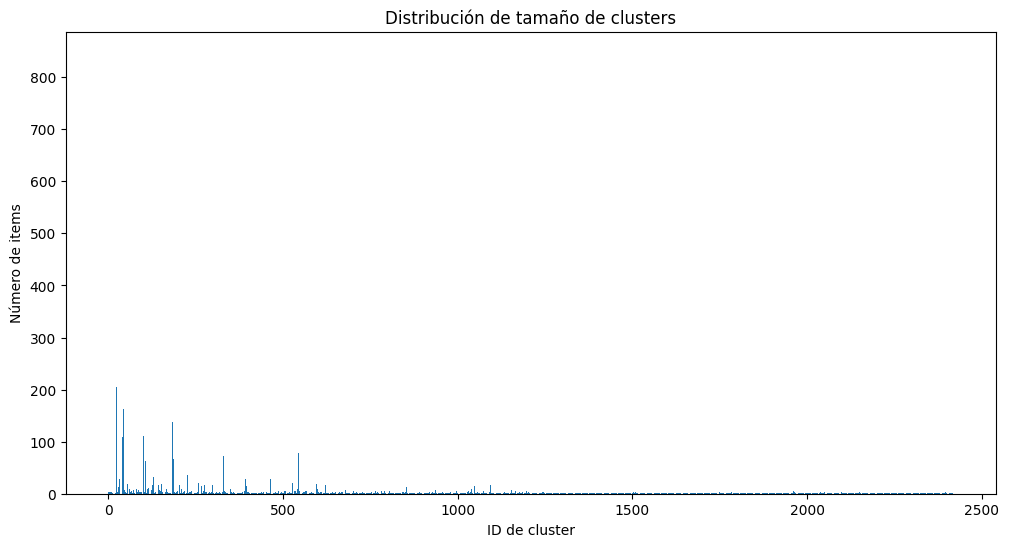

In [ ]:
plot_cluster_distribution(
    sample_equitative_hierarchical, 'cluster_hierarchical'
)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

## DBScan Clustering with Cosine Similarity


In [ ]:
def hdbscan_partition(iterator):
    import numpy as np
    import hdbscan
    data = np.array([x for x in iterator])
    if len(data) == 0:
        return iter([])
    model = hdbscan.HDBSCAN(min_cluster_size=2)
    labels = model.fit_predict(data)
    return iter([(data[i].tolist(), int(labels[i])) for i in range(len(labels))])

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    result_rdd = df_items_features.select("features").rdd.map(lambda r: r.features.toArray()).mapPartitions(hdbscan_partition)
    result_df = result_rdd.toDF(["features", "cluster"])
    
    (
        result_df.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('dbscan_meta_items_clustered_equi', catalog=GOLD_SCHEMA_CLUSTER))
    )

dbscan_meta_items_clustered_equi = spark.read.format('delta').load(spark_utils.path(
    'dbscan_meta_items_clustered_equi', catalog=GOLD_SCHEMA_CLUSTER
))

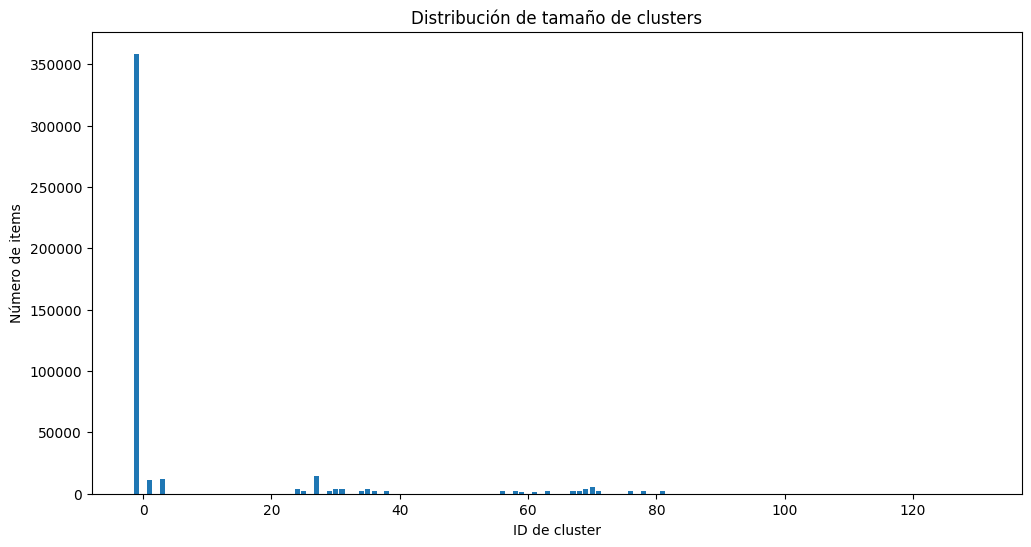

In [ ]:
plot_cluster_distribution(
    dbscan_meta_items_clustered_equi, 'cluster'
)

## ECSAGO Algorithm Implementation


In [ ]:
from src.utils.models.ecsago import ECSAGO

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    sample_data = df_weighted_sample.select("parent_asin", "pca_features").toPandas()
    embeddings_sample = np.vstack(sample_data["pca_features"].values)

    ecsago_model = ECSAGO(
        n_clusters=50,
        max_iter=50,
        num_agents=20,
        chaos_map='logistic',
        convergence_threshold=1e-6,
        random_state=42
    )

    ecsago_labels = ecsago_model.fit_predict(embeddings_sample)

    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

    silhouette_ecsago = silhouette_score(embeddings_sample, ecsago_labels)
    calinski_ecsago = calinski_harabasz_score(embeddings_sample, ecsago_labels)
    davies_bouldin_ecsago = davies_bouldin_score(embeddings_sample, ecsago_labels)

    print("ECSAGO Clustering Metrics:")
    print(f"Silhouette Score: {silhouette_ecsago:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_ecsago:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_ecsago:.4f}")

    ecsago_labels_counts = pd.Series(ecsago_labels).value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    plt.bar(
        ecsago_labels_counts.index,
        ecsago_labels_counts.values
    )
    plt.title('Cluster Size Distribution - ECSAGO')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Items')
    plt.show()

## Selección de clusters resultantes

In [ ]:
resulting_clusters = (
    kmeans_meta_items_clustered_equi
        .select('parent_asin', 'cluster')
)

In [ ]:
if REGENERATE_INTERMEDIATE_TABLES:
    resulting_clusters = model.transform(df_items_features)
    (
        resulting_clusters.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('resulting_clusters', catalog = GOLD_SCHEMA_CLUSTER))
    )

resulting_clusters = spark.read.format('delta').load(spark_utils.path(
    'resulting_clusters', catalog = GOLD_SCHEMA_CLUSTER
))